## Visualizing the quantile discretization method

In this notebook, we inspect the RMSE of the dose-response curves predicted by quantile-binning CausalPFN. As in the uniform bin size method, we average `EPOs_1` and `EPOs_2` to get a single EPO prediction for each discretized treatment value. We do this for the same five datasets (linear, nonlinear, EconML ex 1, debt loss, and ADMIT synthetic). Run the notebook to generate files and figures (requires `epo_df` to exist). 

Note that the DataFrames for the quantile binning strategy have an extra column, `T`, since the discrete treatment values are calculated as the mean of each quantile.

Fix a dataset. For each `N = N_DISC`, we have an approximation to the DRF given by CausalPFN, which is a linear interpolation at the `N` treatment values. We use `scipy.interpolate.interp1d` (legacy) to define the linear interpolations from the data. For each dataset and `N` value, we estimate the RMSE on a fixed `T`-mesh, `rmse_calc_t_mesh`. We use `bounds_error=False` and `fill_value=(y[0], y[-1])`, which sets the extrapolation on `[0, t_vals[0]]` to be constant `y[0]` and on `[t_vals[-1], 1]` to be constant `y[-1]`. Note that with the quantile binning method, as opposed to uniform bin sizes, extrapolation needs to be done almost surely.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from scipy.interpolate import interp1d

In [24]:
## Fix the t-mesh on which to evaluate RMSE
rmse_calc_t_mesh = np.linspace(0, 1, 100)

In [25]:
## Load DataFrames

df_linear = pd.read_csv(
    "..\output\quantile_EPO_df_vahid-linear_11-18_14h53m.csv",
    index_col=[0, 1]
)
df_nonlin = pd.read_csv(
    "..\output\quantile_EPO_df_vahid-nonlinear_11-18_14h59m.csv",
    index_col=[0, 1]
)
df_econML = pd.read_csv(
    "..\output\quantile_EPO_df_econ-ML-ex1_11-18_15h3m.csv",
    index_col=[0, 1]
)
df_debt = pd.read_csv(
    "..\output\quantile_EPO_df_debt-loss_11-18_15h34m.csv",
    index_col=[0, 1]
)
df_admit = pd.read_csv(
    "..\output\quantile_EPO_df_ADMIT-synthetic_11-18_15h12m.csv",
    index_col=[0, 1]
)

In [26]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

In [27]:
# For file naming purposes
month = datetime.datetime.now().month
date = datetime.datetime.now().day
hour = datetime.datetime.now().hour
minute = datetime.datetime.now().minute
date_string = f"{month}-{date}_{hour}h{minute}m"
file_location = "../output"

## Dataset 1: Linear DRF

In [28]:
df = df_linear 
data_name = "vahid-linear"
N_max = df.index[-1][0]
df_drop_T = df[["EPOs_1", "EPOs_2", "true_effect"]] # Just predictions

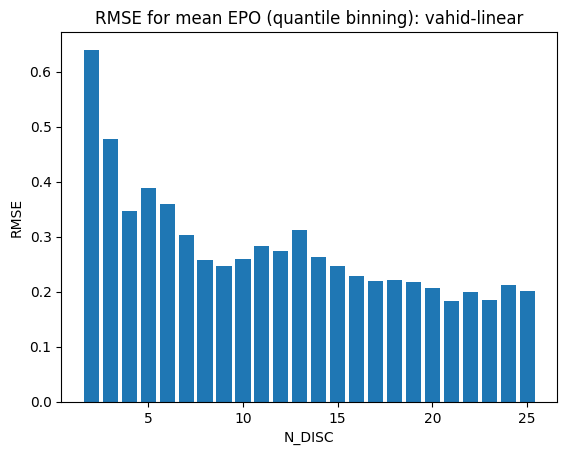

In [29]:
# RMSE calculation on the average EPO

def drf_linear(t): return 3.5 + 3 * t # true dose-response function

rmse_dict = dict() # record RMSE for each N_DISC 
for N_DISC in range(2, N_max + 1):
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    y_true = drf_linear(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

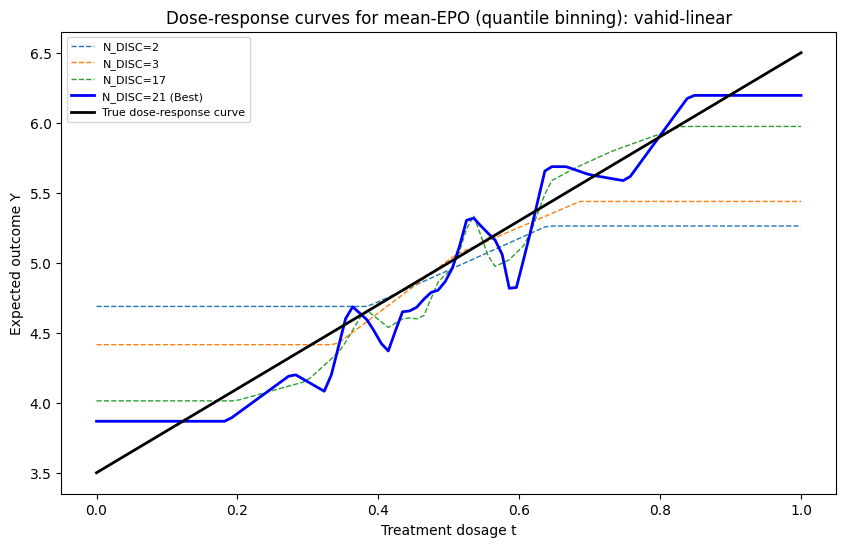

In [30]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 17, 21]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and interpolate; plot using rmse_calc_t_mesh
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(rmse_calc_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(rmse_calc_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
def linear_drf(t): return 3.5 + 3 * t
t_mesh = np.linspace(0, 1, 100)
y_true = linear_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 2: Nonlinear DRF

In [31]:
df = df_nonlin
data_name = "vahid-nonlin"
N_max = df.index[-1][0]
df_drop_T = df[["EPOs_1", "EPOs_2", "true_effect"]] # Just predictions

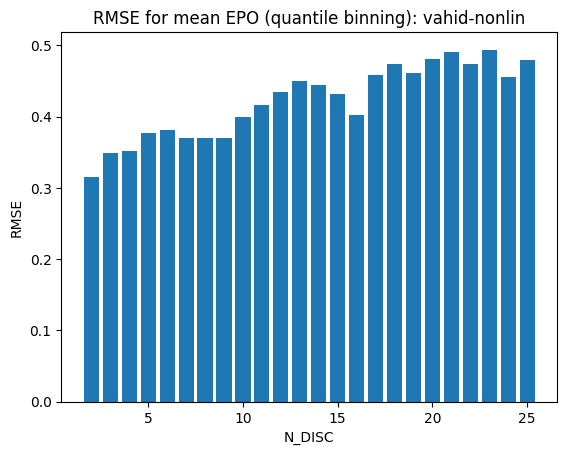

In [32]:
# RMSE calculation on the average EPO

def drf_nonlin(t): return 0.5 * t ** 2 - 2 * t # true dose-response function

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    y_true = drf_nonlin(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

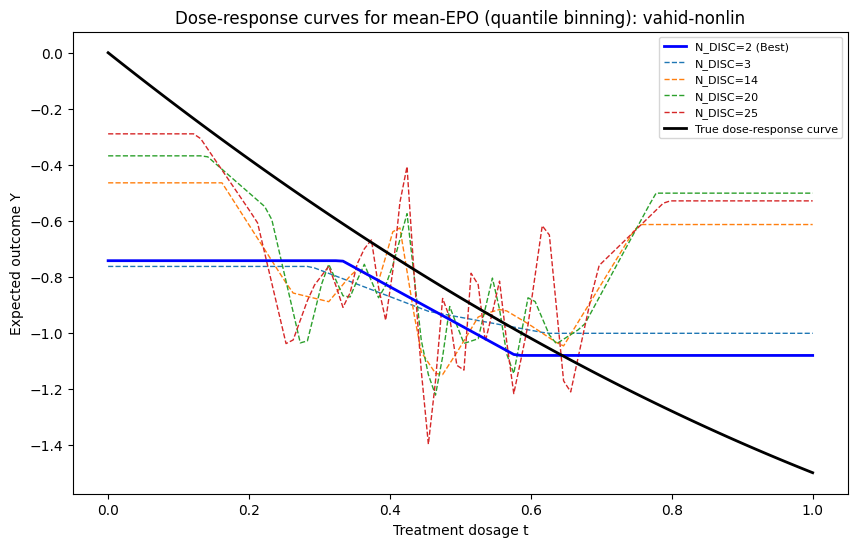

In [33]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 14, 20, 25]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and interpolate; plot using rmse_calc_t_mesh
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(rmse_calc_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(rmse_calc_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
t_mesh = np.linspace(0, 1, 100)
y_true = drf_nonlin(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 3: EconML Ex 1

In [34]:
df = df_econML
data_name = "econ-ML-ex1"
N_max = df.index[-1][0]
df_drop_T = df[["EPOs_1", "EPOs_2", "true_effect"]] # Just predictions

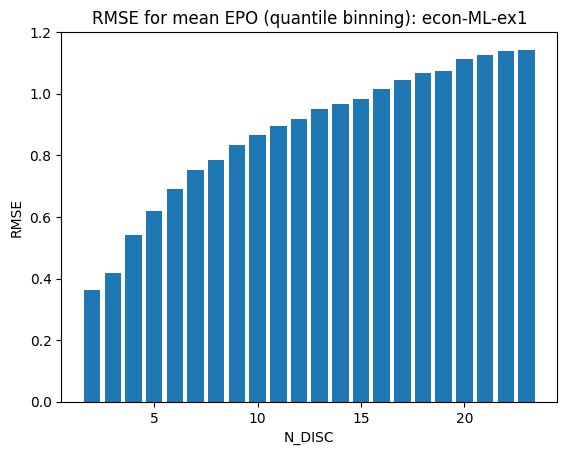

In [35]:
# RMSE calculation on the average EPO

# True dose-response curve (Ran the DGP and got the coefficient of T separately)
def drf_econML(t): return t * 3.21182

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    y_true = drf_econML(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

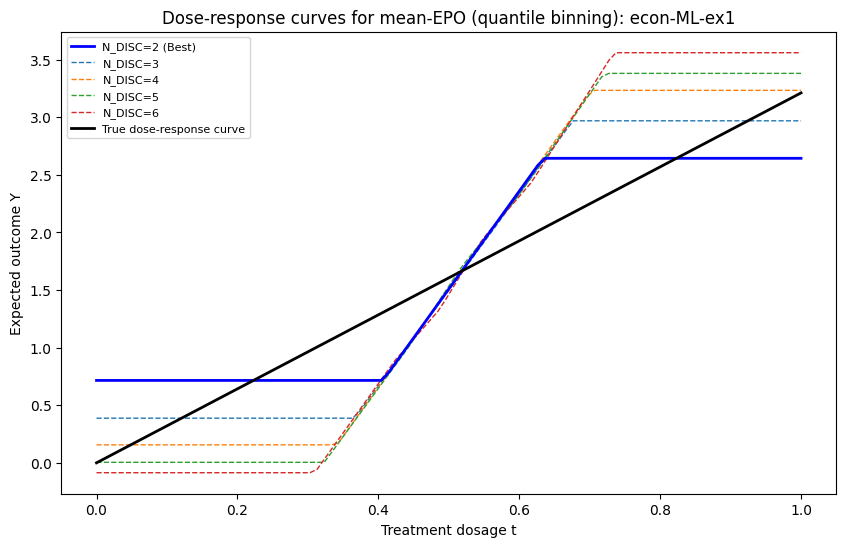

In [36]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 4, 5, 6]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and interpolate; plot using rmse_calc_t_mesh
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(rmse_calc_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(rmse_calc_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (Ran the DGP and got the coefficient of T separately)
t_mesh = np.linspace(0, 1, 100)
y_true = drf_econML(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 4: Debt loss

In [37]:
df = df_debt
data_name = "debt"
N_max = df.index[-1][0]
df_drop_T = df[["EPOs_1", "EPOs_2", "true_effect"]] # Just predictions

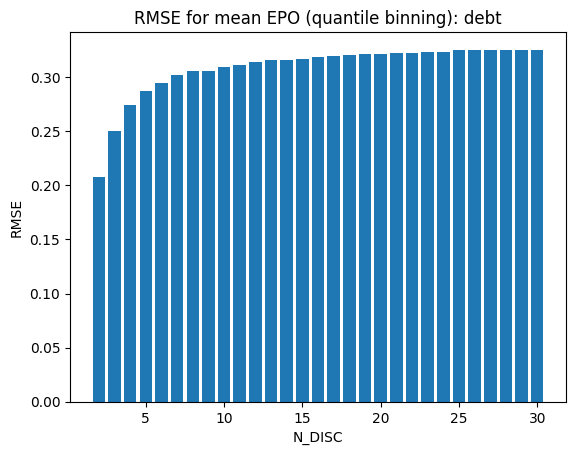

In [38]:
# RMSE calculation on the average EPO


# To get drf_debt (true dose-response), need to re-do DGP
import sys
sys.path.append("../../../my-work/Week_11-17/scripts")
from debt_loss_dgp import DebtDGP, TREATMENT, OUTCOME
generator = DebtDGP()
n = 15000
df_2 = generator.generate_random_financial_data(n) # df name already taken
generator.fit_scalers(df_2)
df_2[TREATMENT] = generator.generate_treatment(df_2, noise=True, noise_scale=0.0, treament_noise_std=0.07)
df_2[OUTCOME + "_probs"], df_2[OUTCOME] = generator.calculate_outcome_probability(df_2, df_2[TREATMENT])
step = 1e-2
bin_edges = np.arange(0, 1+step, step)
real_dose_response = generator.compute_causal_effects(df_2, bin_edges, "ate")
# True dose-response function
y_true_f = interp1d(bin_edges, real_dose_response)
def drf_debt(t): return y_true_f(t)

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    y_true = drf_debt(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

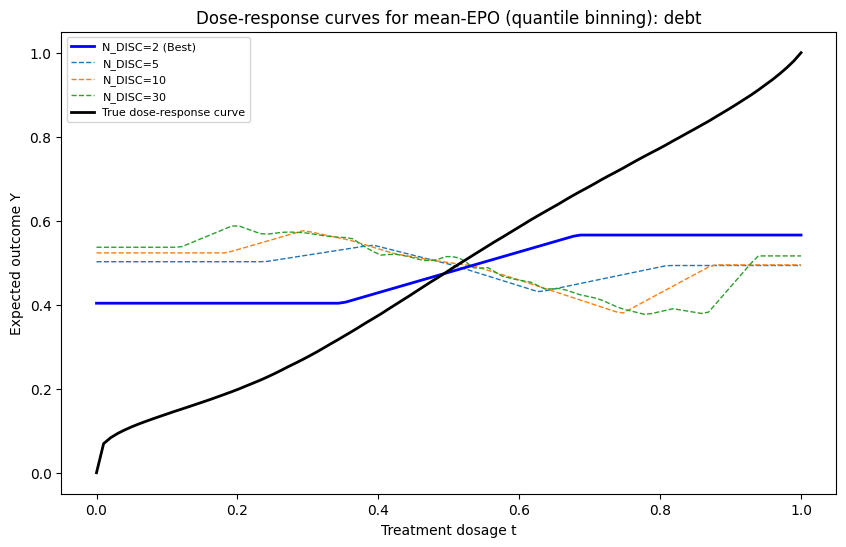

In [39]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 5, 10, 30]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and interpolate; plot using rmse_calc_t_mesh
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(rmse_calc_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(rmse_calc_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")


# True dose-response curve
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, drf_debt(t_mesh),
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 5: ADMIT synthetic dataset

In [40]:
df = df_admit
data_name = "ADMIT-synthetic"
N_max = df.index[-1][0]
df_drop_T = df[["EPOs_1", "EPOs_2", "true_effect"]] # Just predictions

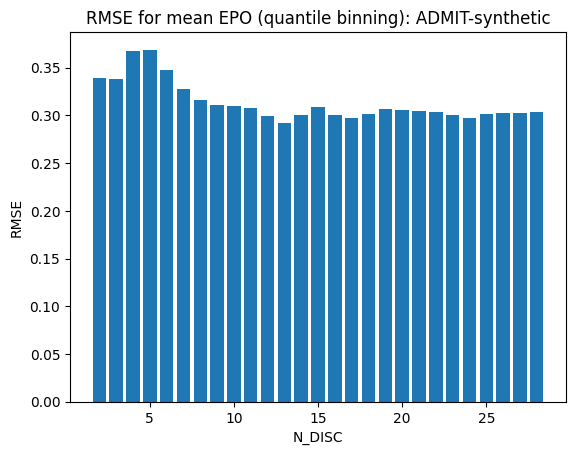

In [41]:
# RMSE calculation on the average EPO

# To get drf_ADMIT (the true dose-response), need to re-do DGP
def sigmoid(t): return 1. / (1. + np.exp(-1. * t))
n, d = 2000, 6
X = np.random.uniform(-1, 1, (n, d))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]
x4 = X[:, 3]
x5 = X[:, 4]
x6 = X[:, 5]
# Generate treatment 
mu_1 =  (10. * np.sin(np.maximum(x1, np.maximum(x2, x3))) + np.maximum(x3, np.maximum(x4, x5))**3)/(1. + (x1 + x5)**2) + np.sin(0.5 * x3) * (1. + np.exp(x4 - 0.5 * x3)) + x3**2 + 2. * np.sin(x4) + 2.*x5 - 6.5
T = np.random.normal(mu_1, 0.5)
T = sigmoid(T)
# Generate outcomes
mu_2 = np.cos(2 * np.pi * (T - 0.5)) * (T ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
Y = np.random.normal(mu_2, 0.5)
# Generated expected potential outcomes empirically
treatment_doses = np.linspace(0, 1, 100)
effects = []
for t in treatment_doses:
    T_intervention = t * np.ones(T.shape)
    mu_2_intervention = np.cos(2 * np.pi * (T_intervention - 0.5)) * (T_intervention ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
    effects.append(mu_2_intervention.mean())
effects = np.array(effects)
drf_ADMIT = interp1d(treatment_doses, effects) # true dose-reponse

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_ADMIT(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

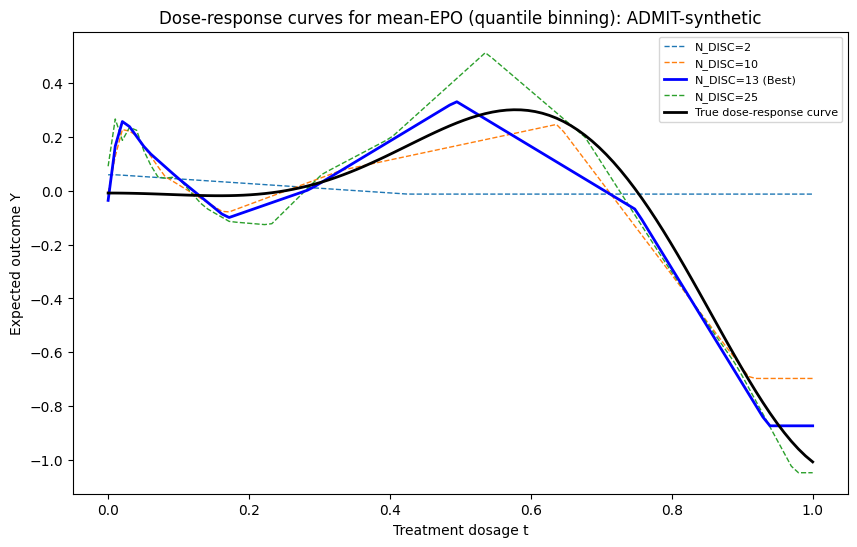

In [42]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 10, 13, 25]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df_drop_T.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and interpolate; plot using rmse_calc_t_mesh
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals_N = df["T"].loc[[N_DISC]].values
    df_N_pred = interp1d(t_vals_N, drf_N_pred_pts,
                         bounds_error=False,
                         fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = df_N_pred(rmse_calc_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(rmse_calc_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(rmse_calc_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
t_mesh = np.linspace(0, 1, 100)
plt.plot(t_mesh, drf_ADMIT(t_mesh),
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()